# Monte Carlo sampling for asymmetric errors

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

In [2]:
# Planck TT data
data_Planck = np.loadtxt('./simulated_maps/experimental_data/COM_PowerSpect_CMB-TT-full_R3.01.txt')
ls_Planck_TT = data_Planck[:, 0]
dl_Planck_TT = data_Planck[:, 1]
sdl_Planck_TT_neg = data_Planck[:, 2]
sdl_Planck_TT_pos = data_Planck[:, 3]
round_ls_Pl_TT = np.round(ls_Planck_TT)

# Planck TE data
data_Planck = np.loadtxt('./simulated_maps/experimental_data/COM_PowerSpect_CMB-TE-full_R3.01.txt')
ls_Planck_TE = data_Planck[:, 0]
dl_Planck_TE = data_Planck[:, 1]
sdl_Planck_TE_neg = data_Planck[:, 2]
sdl_Planck_TE_pos = data_Planck[:, 3]
round_ls_Pl_TE = np.round(ls_Planck_TE)

# Planck EE data
data_Planck = np.loadtxt('./simulated_maps/experimental_data/COM_PowerSpect_CMB-EE-full_R3.01.txt')
ls_Planck_EE = data_Planck[:, 0]
dl_Planck_EE = data_Planck[:, 1]
sdl_Planck_EE_neg = data_Planck[:, 2]
sdl_Planck_EE_pos = data_Planck[:, 3]
round_ls_Pl_EE = np.round(ls_Planck_EE)

In [3]:
#Number of Monte Carlo realizations
num_samples = 10000

#Function to generate asymmetric samples using a skewed normal distribution
def sample_asymmetric_distribution(Dl, err_neg, err_pos, num_samples):
    mean = Dl
    std_dev = (err_pos + err_neg) / 2  # Approximate std deviation
    skew_param = (err_pos - err_neg) / (err_pos + err_neg) * 10  # Skewness factor
    
    # Generate samples
    samples = skewnorm.rvs(a=skew_param, loc=mean, scale=std_dev, size=num_samples)
    return samples

## $\sigma_{\mathcal{C}_{\ell}^{TT}}$ sampling

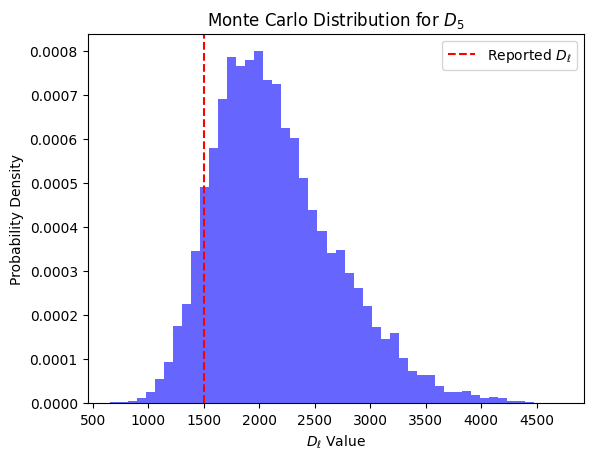

In [6]:
#Generate Monte Carlo samples for each l
samples_dict = {}
for i, l in enumerate(ls_Planck_TT):
    samples_dict[l] = sample_asymmetric_distribution(dl_Planck_TT[i], sdl_Planck_TT_neg[i], sdl_Planck_TT_pos[i], num_samples)

#Example: Plot histogram for one multipole (e.g., l=5)
l_example = 5
plt.hist(samples_dict[l_example], bins=50, density=True, alpha=0.6, color='b')
plt.axvline(dl_Planck_TT[ls_Planck_TT == l_example], color='r', linestyle='dashed', label="Reported $D_\ell$")
plt.xlabel("$D_\ell$ Value")
plt.ylabel("Probability Density")
plt.title(f"Monte Carlo Distribution for $D_{l_example}$")
plt.legend()
plt.show()